In [74]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import compute_zonolayer_bounds
from sklearn.model_selection import train_test_split
from SLINN import SLINN, midrad

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [75]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=6):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        
        if return_features:
            return out, features
        return out
    
class ZonoLayer(nn.Module):
    def __init__(self, hidden_dim=6, zono_dim=3):
        super().__init__()
        self.linear = nn.Linear(hidden_dim, zono_dim)

    def forward(self, features):
        return self.linear(features)
    

def train_centre(
    x_t,
    y_lb_t,
    y_ub_t,
    epochs=3000,
    lr=0.01,
    print_every=100
):
    # Make sure targets are (n, 1)
    y_lb_t = y_lb_t.reshape(-1, 1)
    y_ub_t = y_ub_t.reshape(-1, 1)

    y_mid = (y_lb_t + y_ub_t) / 2

    centre_net = RegressionNetwork(input_dim=x_t.shape[1])

    optimizer = torch.optim.Adam(
        centre_net.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)

        # pred and y_mid are both (n, 1)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1}: "
                f"MSE = {loss.item():.6f}, "
                f"RMSE = {torch.sqrt(loss).item():.2f}"
            )

    return centre_net

def train_zonolayer(
    centre_net,
    x_t,
    y_lb_t,
    y_ub_t,
    zono_dim=3,
    epochs=300,
    lr=1e-2,
    print_every=50
):
    for p in centre_net.parameters():
        p.requires_grad = False

    centre_net.eval()

    with torch.no_grad():
        _, features = centre_net(x_t, return_features=True)

    hidden_dim = centre_net.regressor.in_features

    # Make targets (n, 1)
    y_lb_t = y_lb_t.reshape(-1, 1)
    y_ub_t = y_ub_t.reshape(-1, 1)

    y_mid = (y_lb_t + y_ub_t) / 2

    zono_layer = ZonoLayer(
        hidden_dim=hidden_dim,
        zono_dim=zono_dim
    )

    # Initialise first zonotope dimension
    with torch.no_grad():
        zono_layer.linear.weight[0:1, :] = (
            centre_net.regressor.weight.data
        )

        zono_layer.linear.bias[0:1] = (
            centre_net.regressor.bias.data
        )

    optimizer = torch.optim.Adam(
        zono_layer.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    for epoch in range(epochs):
        zono_layer.train()

        pred = zono_layer(features)[:, 0:1]

        # Both are (n, 1)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(
                f"Zono epoch {epoch+1}: "
                f"MSE = {loss.item():.6f}, "
                f"RMSE = {torch.sqrt(loss).item():.2f}"
            )

    return zono_layer

In [76]:
df = pd.read_csv('Data/AmesHousing.csv')
df.head()

X = df[['Year Built']].values.astype(np.float32)

# Scale X
X_mean = X.mean()
X_std = X.std()
X = (X - X_mean) / X_std

# Original interval data
y = df['SalePrice'].values.astype(np.float32)

Delta = np.abs(
    np.random.normal(15000, 10000, len(df))
)

b = np.random.uniform(-1, 1, size=len(df))

m = y + b * Delta

y_lower = m - Delta
y_upper = m + Delta

# Scale y using the original SalePrice statistics
y_mean = y.mean()
y_std = y.std()

y_scaled = (y - y_mean) / y_std
y_lower_scaled = (y_lower - y_mean) / y_std
y_upper_scaled = (y_upper - y_mean) / y_std

X_train, X_test, \
y_train, y_test, \
y_lower_train, y_lower_test, \
y_upper_train, y_upper_test = train_test_split(
    X,
    y_scaled,
    y_lower_scaled,
    y_upper_scaled,
    test_size=0.2,
    random_state=42
)

x_t = torch.tensor(X_train, dtype=torch.float32)

y_lb_t = torch.tensor(
    y_lower_train,
    dtype=torch.float32
).reshape(-1, 1)

y_ub_t = torch.tensor(
    y_upper_train,
    dtype=torch.float32
).reshape(-1, 1)


def extract_zono_predictions(centre_net, zono_layer, x):
    centre_net.eval()
    zono_layer.eval()
    with torch.no_grad():
        pred, features = centre_net(x, return_features=True)
        features = zono_layer(features)
    return pred.numpy(), features.numpy()

# Zonolayer computation
centre_net = train_centre(x_t, y_lb_t, y_ub_t)
zono_layer = train_zonolayer(centre_net, x_t, y_lb_t, y_ub_t, zono_dim=3)


pred_train, latent_train = extract_zono_predictions(centre_net, zono_layer, x_t)
pred_test, latent_test = extract_zono_predictions(centre_net, zono_layer, torch.tensor(X_test, dtype=torch.float32))
zonolayer = compute_zonolayer_bounds(latent_train, y_lower_train, y_upper_train, latent_test)

yl_zl = zonolayer["y_lower"].squeeze()
yu_zl = zonolayer["y_upper"].squeeze()
midpoint_model = zonolayer["midpoint"].squeeze()




# ============================================================
# SLINN
# ============================================================

x_slinn_train = np.asarray(
    x_slinn_train,
    dtype=np.float64
).reshape(-1, 1)

x_slinn_test = np.asarray(
    x_slinn_test,
    dtype=np.float64
).reshape(-1, 1)

y_lower_slinn = np.asarray(
    y_lower_train,
    dtype=np.float64
).reshape(-1, 1)

y_upper_slinn = np.asarray(
    y_upper_train,
    dtype=np.float64
).reshape(-1, 1)


# Interval-valued target
Y1_train = midrad(
    (y_lower_slinn + y_upper_slinn) / 2,
    (y_upper_slinn - y_lower_slinn) / 2
)


# ------------------------------------------------------------
# SLINN network
# ------------------------------------------------------------

net1 = SLINN(
    1,
    6,
    1,
    L=2,
    L_rate=0.0001
)

print("Training SLINN on House Prices...")

net1.train(
    x_slinn_train,
    Y1_train,
    epochs=3000
)


# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------

p_slinn = net1.predict(
    x_slinn_test,
    Y1_train
)

slinn_lo = (
    p_slinn.mid - p_slinn.rad
).ravel()

slinn_mid = p_slinn.mid.ravel()

slinn_hi = (
    p_slinn.mid + p_slinn.rad
).ravel()


# ------------------------------------------------------------
# Denormalise SalePrice
# ------------------------------------------------------------

slinn_lo = slinn_lo * y_std + y_mean
slinn_mid = slinn_mid * y_std + y_mean
slinn_hi = slinn_hi * y_std + y_mean


Epoch 100: MSE = 0.602562, RMSE = 0.78
Epoch 200: MSE = 0.600321, RMSE = 0.77
Epoch 300: MSE = 0.600190, RMSE = 0.77
Epoch 400: MSE = 0.600106, RMSE = 0.77
Epoch 500: MSE = 0.600041, RMSE = 0.77
Epoch 600: MSE = 0.599993, RMSE = 0.77
Epoch 700: MSE = 0.599956, RMSE = 0.77
Epoch 800: MSE = 0.599925, RMSE = 0.77
Epoch 900: MSE = 0.599899, RMSE = 0.77
Epoch 1000: MSE = 0.599875, RMSE = 0.77
Epoch 1100: MSE = 0.599854, RMSE = 0.77
Epoch 1200: MSE = 0.599834, RMSE = 0.77
Epoch 1300: MSE = 0.599816, RMSE = 0.77
Epoch 1400: MSE = 0.599799, RMSE = 0.77
Epoch 1500: MSE = 0.599782, RMSE = 0.77
Epoch 1600: MSE = 0.599766, RMSE = 0.77
Epoch 1700: MSE = 0.599751, RMSE = 0.77
Epoch 1800: MSE = 0.599735, RMSE = 0.77
Epoch 1900: MSE = 0.599721, RMSE = 0.77
Epoch 2000: MSE = 0.599707, RMSE = 0.77
Epoch 2100: MSE = 0.599693, RMSE = 0.77
Epoch 2200: MSE = 0.599681, RMSE = 0.77
Epoch 2300: MSE = 0.599668, RMSE = 0.77
Epoch 2400: MSE = 0.599657, RMSE = 0.77
Epoch 2500: MSE = 0.599646, RMSE = 0.77
Epoch 260

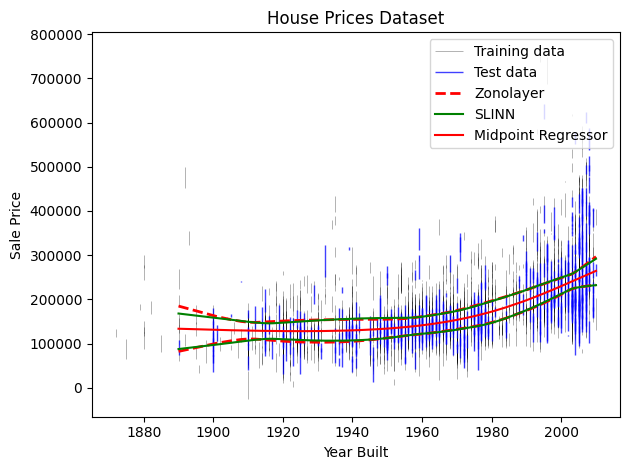

In [77]:
x_train = np.asarray(X_train).squeeze()
x_test = np.asarray(X_test).squeeze()

y_train_plot = np.asarray(y_train).squeeze()
y_test_plot = np.asarray(y_test).squeeze()

y_lower_train_plot = np.asarray(y_lower_train).squeeze()
y_upper_train_plot = np.asarray(y_upper_train).squeeze()

y_lower_test_plot = np.asarray(y_lower_test).squeeze()
y_upper_test_plot = np.asarray(y_upper_test).squeeze()

pred_train = np.asarray(pred_train).squeeze()
pred_test = np.asarray(pred_test).squeeze()

yl_zl = np.asarray(yl_zl).squeeze()
yu_zl = np.asarray(yu_zl).squeeze()
midpoint_model = np.asarray(midpoint_model).squeeze()

# X was standardised as:
# X_scaled = (X - X_mean) / X_std

x_train = x_train * X_std + X_mean
x_test = x_test * X_std + X_mean


# y was standardised as:
# y_scaled = (y - y_mean) / y_std

y_train_plot = y_train_plot * y_std + y_mean
y_test_plot = y_test_plot * y_std + y_mean

y_lower_train_plot = (
    y_lower_train_plot * y_std + y_mean
)

y_upper_train_plot = (
    y_upper_train_plot * y_std + y_mean
)

y_lower_test_plot = (
    y_lower_test_plot * y_std + y_mean
)

y_upper_test_plot = (
    y_upper_test_plot * y_std + y_mean
)

pred_train = pred_train * y_std + y_mean
pred_test = pred_test * y_std + y_mean

yl_zl = yl_zl * y_std + y_mean
yu_zl = yu_zl * y_std + y_mean
midpoint_model = midpoint_model * y_std + y_mean



train_idx = np.argsort(x_train)
test_idx = np.argsort(x_test)

x_train_sorted = x_train[train_idx]
x_test_sorted = x_test[test_idx]

y_train_sorted = y_train_plot[train_idx]
y_test_sorted = y_test_plot[test_idx]

y_lower_train_sorted = y_lower_train_plot[train_idx]
y_upper_train_sorted = y_upper_train_plot[train_idx]

y_lower_test_sorted = y_lower_test_plot[test_idx]
y_upper_test_sorted = y_upper_test_plot[test_idx]

pred_train_sorted = pred_train[train_idx]
pred_test_sorted = pred_test[test_idx]

yl_zl_sorted = yl_zl[test_idx]
yu_zl_sorted = yu_zl[test_idx]

midpoint_model_sorted = midpoint_model[test_idx]

slinn_lo_sorted = slinn_lo[test_idx]
slinn_hi_sorted = slinn_hi[test_idx]
slinn_mid_sorted = slinn_mid[test_idx]



plt.figure()


plt.vlines(
    x_train_sorted,
    y_lower_train_sorted,
    y_upper_train_sorted,
    color='black',
    alpha=0.35,
    linewidth=0.6,
    label='Training data'
)

plt.vlines(
    x_test_sorted,
    y_lower_test_sorted,
    y_upper_test_sorted,
    color='blue',
    alpha=0.75,
    linewidth=1.0,
    label='Test data'
)

plt.plot(
    x_test_sorted,
    yl_zl_sorted,
    'r--',
    linewidth=2,
    label='Zonolayer'
)

plt.plot(
    x_test_sorted,
    yu_zl_sorted,
    'r--',
    linewidth=2
)

plt.plot(
    x_test_sorted,
    slinn_lo_sorted,
    color='green',
    linestyle='-',
    linewidth=1.5,
    label='SLINN'
)

# SLINN upper bound
plt.plot(
    x_test_sorted,
    slinn_hi_sorted,
    color='green',
    linestyle='-',
    linewidth=1.5
)


plt.plot(
    x_test_sorted,
    midpoint_model_sorted,
    'r-',
    linewidth=1.5,
    label='Midpoint Regressor'
)


plt.xlabel('Year Built')
plt.ylabel('Sale Price')

plt.legend()
plt.title("House Prices Dataset")
plt.tight_layout()

plt.savefig(
    "HousePricesNN.pdf",
    bbox_inches="tight"
)
plt.show()
